In [1]:
import pandas as pd
import urllib
import numpy as np
import matplotlib.pyplot as  plt
import os
import PIL
import boto3
from io import BytesIO
import tensorflow as tf
from skimage.color import rgb2gray
import random
import cv2

ModuleNotFoundError: No module named 'pandas'

In [2]:
cut_off=256
offset=256


imagees_org=[]
imagees_clean=[]

conn = boto3.client('s3')
bucket='kevin-datascience'

for File_Name in conn.list_objects(Bucket=bucket, Prefix='Cleaned ECG')['Contents']:
    # for Original Images as X for training
    

    with BytesIO() as f:
        boto3.client("s3").download_fileobj(Bucket=bucket, Key='Cropped Reports/'+File_Name['Key'].split('/')[1], Fileobj=f)
        f.seek(0)
        img = rgb2gray(plt.imread(f, format='jpg'))


    cropped_image_orginal=tf.image.resize(img.reshape(img.shape[0],img.shape[1],1),[256,2048])


    for i in range(8):
        imagees_org.append(cropped_image_orginal[:,i*cut_off:cut_off+i*offset])

    # for Cleaned Images as Y for training

    with BytesIO() as f:
        boto3.client("s3").download_fileobj(Bucket=bucket, Key='Cleaned ECG/'+File_Name['Key'].split('/')[1], Fileobj=f)
        f.seek(0)
        img = rgb2gray(plt.imread(f, format='jpg'))


    cropped_image_clean=tf.image.resize(img.reshape(img.shape[0],img.shape[1],1),[256,2048])


    for i in range(8):
        imagees_clean.append(cropped_image_clean[:,i*cut_off:cut_off+i*offset])

images_org=np.stack(imagees_org,axis=0)
images_clean=np.stack(imagees_clean,axis=0)

2024-05-25 12:39:03.662001: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [4]:
images_org=np.load('orginal.npy')
images_clean=np.load('clean.npy')

In [5]:
images_clean.shape

(2312, 256, 256, 1)

In [6]:
images_org=images_org/255
images_clean=images_clean/255

In [ ]:
range_size=images_clean.shape[0]
train_percent=0.8
train_list=random.sample(range(range_size),int(range_size*train_percent))
test_list=list(set(range(range_size))-set(train_list))
train_image_org=images_org[train_list]
train_image_clean=images_clean[train_list]
test_image_org=images_org[test_list]
test_image_clean=images_clean[test_list]

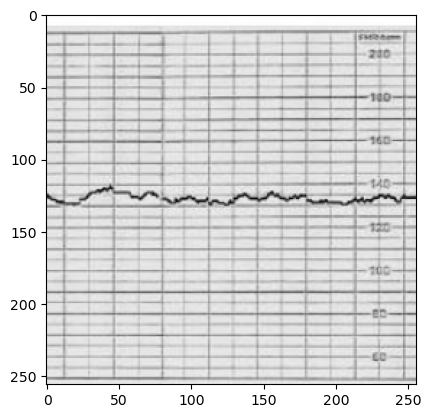

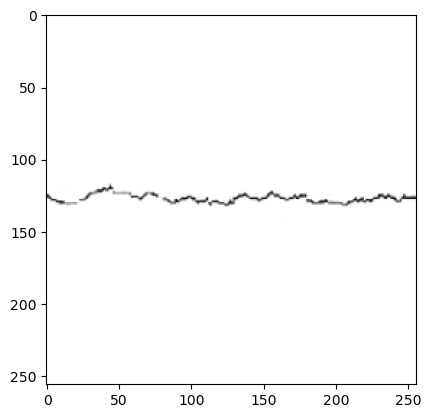

In [7]:
index=np.random.randint(0,images_clean.shape[0])

plt.imshow(images_org[index],cmap='gray')
plt.show()
plt.imshow(images_clean[index],cmap='gray')
plt.show()

In [8]:
IMG_HEIGHT = images_clean.shape[1]
IMG_WIDTH  = images_clean.shape[2]
IMG_CHANNELS = images_clean.shape[3]

input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

In [9]:
input_shape

(256, 256, 1)

In [10]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda
from keras.optimizers import Adam
from keras.layers import Activation, MaxPool2D, Concatenate



def conv_block(input, num_filters):
    x = Conv2D(num_filters, 3, padding="same")(input)
    x = BatchNormalization()(x)   #Not in the original network.
    x = Activation("relu")(x)

    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)  #Not in the original network
    x = Activation("relu")(x)

    return x

#Encoder block: Conv block followed by maxpooling


def encoder_block(input, num_filters):
    x = conv_block(input, num_filters)
    p = MaxPool2D((2, 2))(x)
    return x, p

#Decoder block
#skip features gets input from encoder for concatenation

def decoder_block(input, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input)
    x = Concatenate()([x, skip_features])
    x = conv_block(x, num_filters)
    return x

#Build Unet using the blocks
def build_unet(input_shape, n_classes):
    inputs = Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    b1 = conv_block(p4, 1024) #Bridge

    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    if n_classes == 1:  #Binary
      activation = 'sigmoid'
    else:
      activation = 'softmax'

    outputs = Conv2D(n_classes, 1, padding="same", activation=activation)(d4)  #Change the activation based on n_classes
    print(activation)

    model = Model(inputs, outputs, name="U-Net")
    return model

In [11]:
model = build_unet(input_shape, n_classes=1)
model.compile(optimizer=Adam(learning_rate = 1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

2024-05-25 13:17:31.484357: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


sigmoid
Model: "U-Net"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 1)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 64)         640       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 64)         256       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 256, 256, 64)         0         ['batch_normalizat

In [1]:
history=model.fit(train_images_org,train_image_clean,
                  batch_size=16,
                  verbose=1,
                  epochs=100,
                  validation_data=(test_image_org,test_image_clean),
                  shuffle=False

)

NameError: name 'model' is not defined